In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd

In [ ]:
df = pd.read_csv("data/simulated_queue.csv")

In [ ]:
features = ["position", "avg_consult_mins", "doctor_speed", "time_of_day", "day_of_week"]
X = df[features]
y = df["actual_wait_time"]

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35)

NameError: name 'train_test_split' is not defined

In [ ]:
X_train

,doctor_id,position,avg_consult_mins,doctor_speed,time_of_day,day_of_week
735,8,9,30,1.146042,15,1
256,4,8,20,0.951376,21,3
1230,2,1,30,0.796547,14,1
1064,8,4,10,1.451442,9,5
921,6,11,10,0.889088,13,3
...,...,...,...,...,...,...
959,2,5,30,0.698406,16,3
1004,0,6,15,0.884682,15,4
1057,5,4,8,0.589671,14,6
951,1,1,20,0.761432,15,0


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression:")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")

Linear Regression:
MAE: 38.91
RMSE: 54.61


In [8]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("XGBoost:")
print(f"MAE: {mean_absolute_error(y_test, xgb_preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, xgb_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_preds)):.2f}")

XGBoost:
MAE: 9.58
MSE: 235.90
RMSE: 15.36


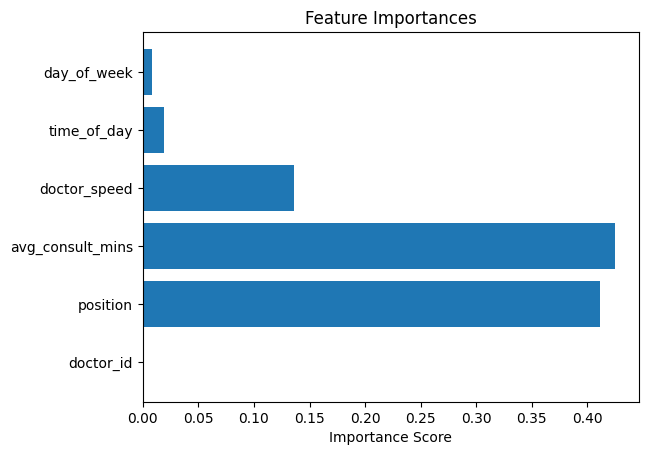

In [9]:
import matplotlib.pyplot as plt

plt.barh(features, xgb.feature_importances_)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [10]:
joblib.dump(xgb, "models/wait_time_model.pkl")

['models/wait_time_model.pkl']